# HW#2-6: 영상에서 원하는 선분 제거

wirebond-mask 영상에서 가느다란 wire 선분을 제거한다.  
모폴로지 연산(Opening)을 활용하여 얇은 구조를 제거하는 방법을 적용한다.

Image shape: (486, 486), dtype: uint8


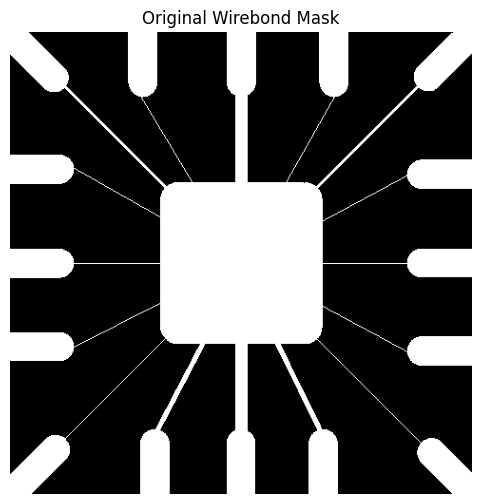

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 영상 로드
img = cv2.imread('data/Fig0905(a)(wirebond-mask).tif', cv2.IMREAD_GRAYSCALE)
print(f'Image shape: {img.shape}, dtype: {img.dtype}')

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title('Original Wirebond Mask')
plt.axis('off')
plt.show()

## 방법 1: 모폴로지 Opening

Opening = Erosion → Dilation  
구조 요소(SE)보다 작은 밝은 구조물이 제거된다. wire는 얇은 선이므로 적절한 크기의 SE로 Opening하면 제거 가능하다.

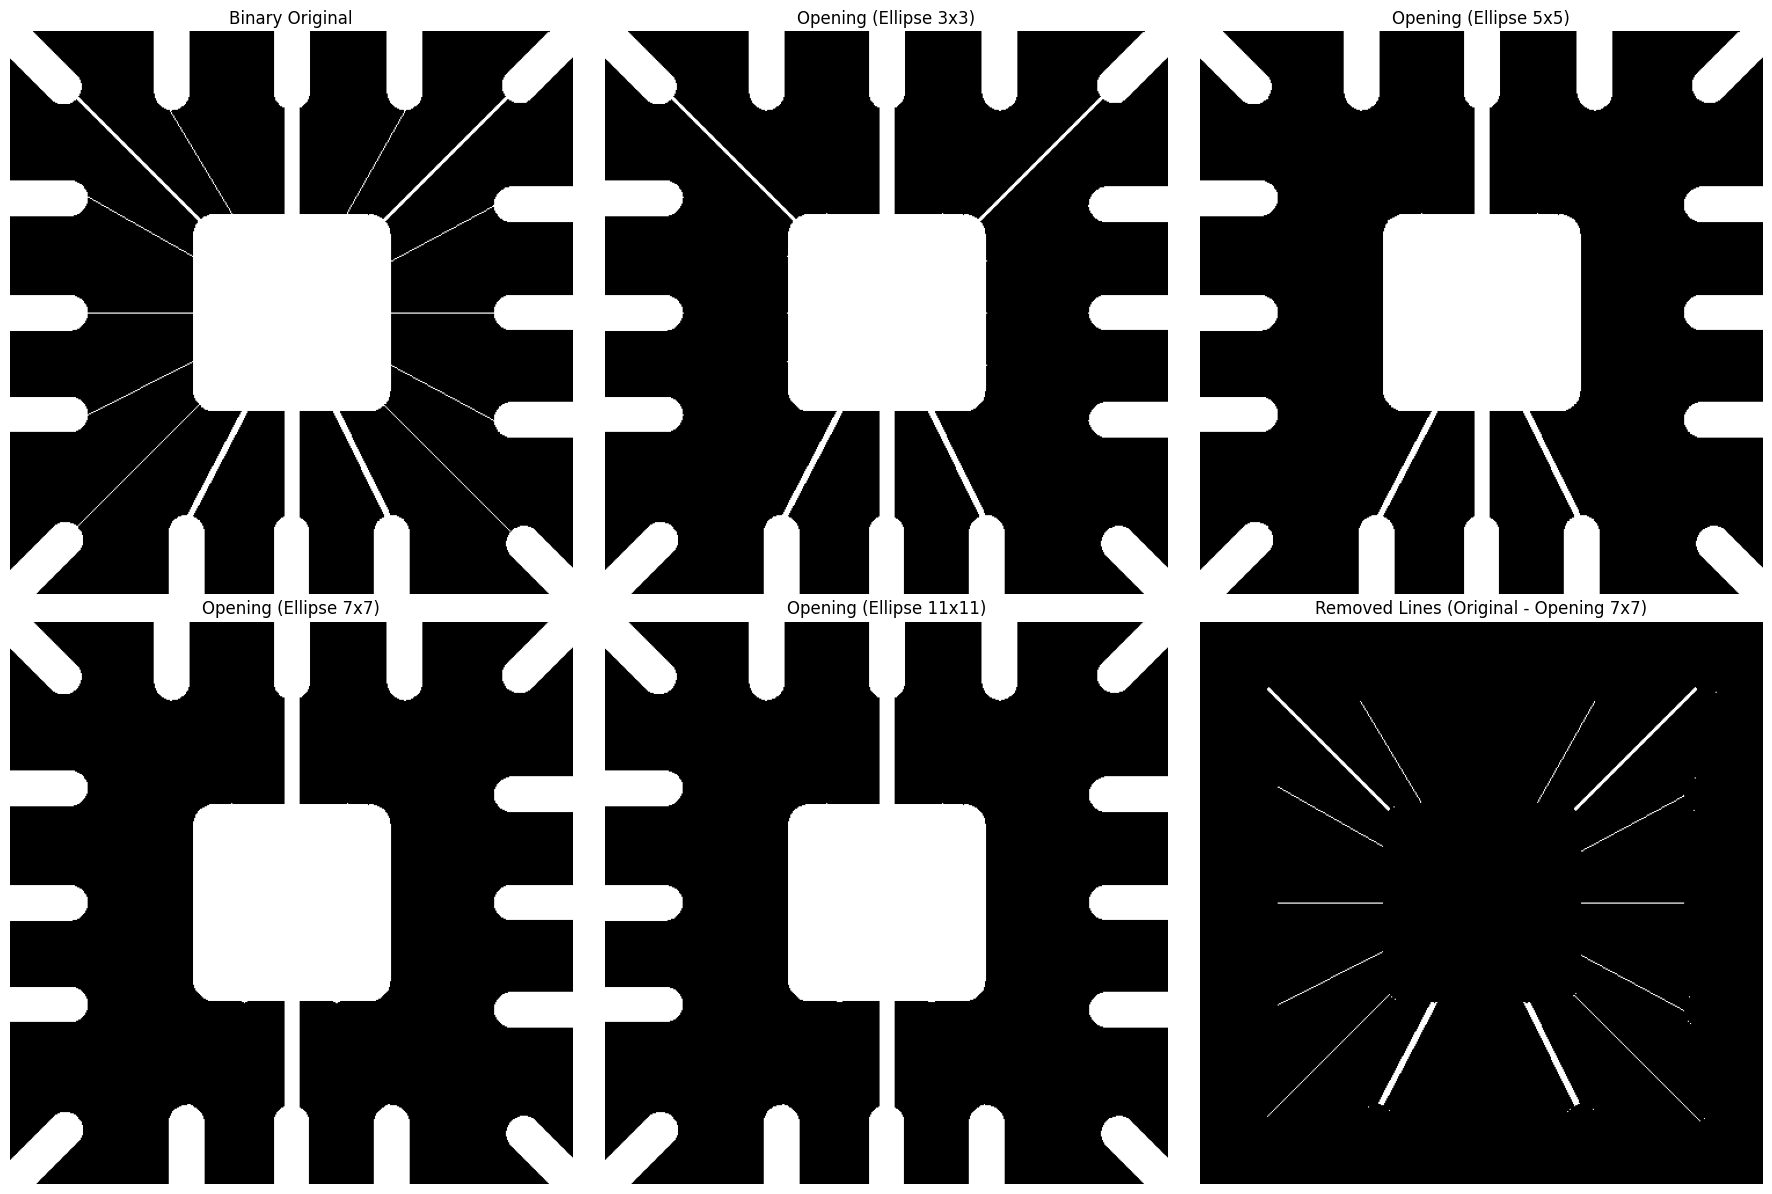

In [2]:
# 이진화 (이미 거의 이진 영상이지만 확실히)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 다양한 크기의 원형 구조 요소로 Opening
results = []
kernel_sizes = [3, 5, 7, 11]

for ks in kernel_sizes:
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ks, ks))
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    results.append(opened)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(binary, cmap='gray')
axes[0, 0].set_title('Binary Original')
axes[0, 0].axis('off')

for i, (res, ks) in enumerate(zip(results, kernel_sizes)):
    row, col = divmod(i + 1, 3)
    axes[row, col].imshow(res, cmap='gray')
    axes[row, col].set_title(f'Opening (Ellipse {ks}x{ks})')
    axes[row, col].axis('off')

# 제거된 선분만 보기 (원본 - opening)
removed = binary - results[2]  # 7x7 결과 사용
axes[1, 2].imshow(removed, cmap='gray')
axes[1, 2].set_title('Removed Lines (Original - Opening 7x7)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## 방법 2: 방향별 선분 제거 (특정 방향 SE 활용)

특정 방향의 선만 선택적으로 제거하려면, 해당 방향의 선형 구조 요소를 사용한다.  
예: 수직선 제거 → 수평 SE로 Opening, 대각선 제거 → 대각 SE로 Opening

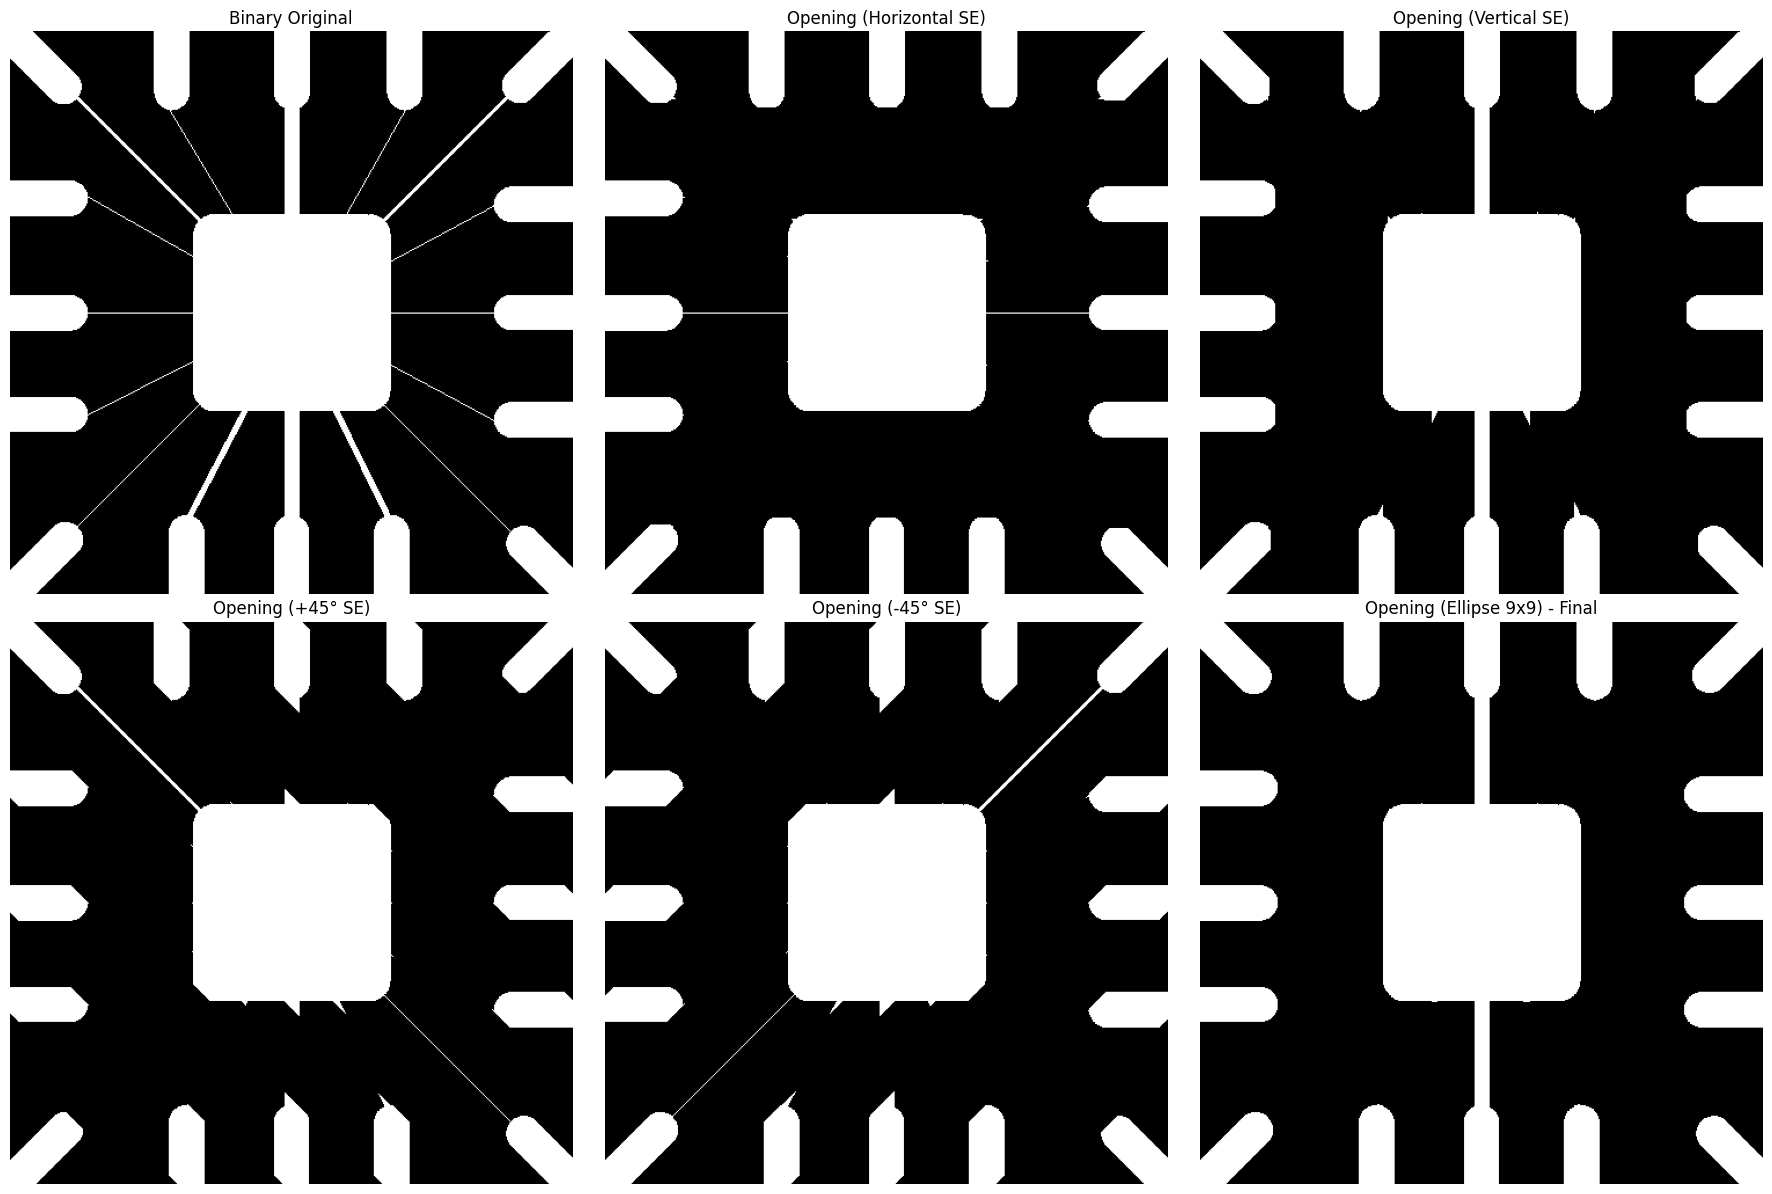

In [3]:
# 방향별 구조 요소 생성
length = 15

# 수평 SE
kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (length, 1))
# 수직 SE
kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, length))
# 대각선 SE (+45°)
kernel_d45 = np.eye(length, dtype=np.uint8)
# 대각선 SE (-45°)
kernel_dn45 = np.fliplr(np.eye(length, dtype=np.uint8))

opened_h = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_h)
opened_v = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_v)
opened_d45 = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_d45)
opened_dn45 = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_dn45)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(binary, cmap='gray')
axes[0, 0].set_title('Binary Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(opened_h, cmap='gray')
axes[0, 1].set_title('Opening (Horizontal SE)')
axes[0, 1].axis('off')

axes[0, 2].imshow(opened_v, cmap='gray')
axes[0, 2].set_title('Opening (Vertical SE)')
axes[0, 2].axis('off')

axes[1, 0].imshow(opened_d45, cmap='gray')
axes[1, 0].set_title('Opening (+45° SE)')
axes[1, 0].axis('off')

axes[1, 1].imshow(opened_dn45, cmap='gray')
axes[1, 1].set_title('Opening (-45° SE)')
axes[1, 1].axis('off')

# 모든 방향 제거 결과 합성
# Opening은 해당 방향의 구조만 남기므로, 선분을 제거하려면 다른 접근
# 원형 SE opening이 가장 효과적
kernel_circle = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
final_opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_circle)
axes[1, 2].imshow(final_opened, cmap='gray')
axes[1, 2].set_title('Opening (Ellipse 9x9) - Final')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('result/hw2_6_result.png', dpi=150, bbox_inches='tight')
plt.show()

## 결과 분석

**모폴로지 Opening 원리:**  
Opening(Erosion + Dilation)은 구조 요소보다 작은 밝은 객체를 제거한다. wire는 폭이 매우 좁은 선분이므로, 적절한 크기의 SE로 Opening하면 wire가 erosion 단계에서 사라지고, dilation에서도 복원되지 않는다.

**SE 크기에 따른 차이:**  
- 3x3: wire의 일부가 남을 수 있음
- 5x5~7x7: 대부분의 wire가 제거됨
- 11x11: wire는 완전히 제거되지만 pad 등 작은 구조물도 손상될 수 있음

**방향별 SE:**  
선형 SE를 사용하면 특정 방향의 구조만 남기거나 제거할 수 있다. 그러나 wirebond 영상의 wire는 다양한 방향을 가지므로, 원형 SE의 Opening이 가장 효과적이다.

**최적 결과:**  
원형 SE 7~9 크기의 Opening이 wire를 제거하면서도 pad/die 구조를 잘 보존한다.